# Quick start tutorial for anatomical analysis
This tutorial shows how to use SUITPy to preprocess anatomical MRI data
for cerebellar deformation-based morphometry (DBM). It covers the
single-subject pipeline and describes how the outputs feed into
group-level analysis.

It involves the following steps:

* Isolate the cerebellum
* Normalize and compute the Jacobian determinant (detJ)
* Group-level analysis
* Visualize individual volume differences on the flatmap
* Summarize regional volume with atlas ROI

To start you need:
* An anatomical T1-weighted image of each subject (``sub-ex_T1w.nii.gz``)

*Note: You can find additional details and explanations for each step in the corresponding sections of the documentation.*


## Getting set up 
Install SUITPy

`pip install SUITPy`

For detailed instructions and dependencies, see `Installation`.

In [1]:
# Import necessary packages
import os
import numpy as np
import nibabel as nib
import nilearn.plotting as npl
import matplotlib.pyplot as plt
import SUITPy as suit

## 1. Isolate the cerebellum
The first step is to use ``isolate`` to create a cerebellum–brainstem mask from the anatomical image. The mask is required for normalization and helps avoid signal spillover from nearby cortex.

In [3]:
# This function generates isolation mask for the cerebellum based on a T1 scan
suit.isolate('sub-ex_T1w.nii.gz')

preprocessing
isolating cerebellum using UNet model
postprocessing
saving results to sub-ex_T1w_cerebellum_dseg.nii.gz


The mask is saved as ``sub-ex_T1w_cerebellum_dseg.nii.gz`` in the same folder as the anatomical scan.

Although the isolation algorithm works very reliably and usually does not require any correction, it is good practice to check the mask.


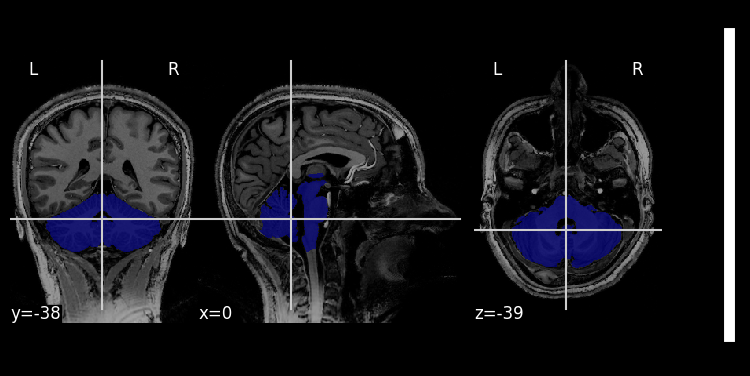

In [3]:
# Visualize the mask on the T1 image
img  = nib.load('sub-ex_T1w.nii.gz')
mask = nib.load('sub-ex_T1w_cerebellum_dseg.nii.gz')
npl.plot_roi(mask, img)


## 2. Normalize and compute the Jacobian determinant (detJ)

The SUIT normalization module estimates a nonlinear deformation field that
aligns each subject's cerebellum to the SUIT template. From this field, it
computes the **Jacobian determinant (detJ) map**, which encodes local volumetric
differences relative to the template: values greater than 1 indicate that the subject's local volume is larger than the template; values less than 1 indicate smaller volume.

The detJ is computed analytically from the deformation field (**geometric** method)
rather than by finite differences, giving a more stable estimate for morphometric
analysis.


In [6]:
# This function normalizes a source image to the SUIT cerebellar template using a provided cerebellum
results = suit.normalize(source_file = 'sub-ex_T1w.nii.gz',
                         mask_file = 'sub-ex_T1w_cerebellum_dseg.nii.gz',
                         write_jacobian_determinant=True,
                         write_log_jacobian_determinant=True)

Normalizing sub-ex_T1w to tpl-SUIT_T1w.nii.gz
Saving the normalized image into sub-ex_T1w_space-SUIT.nii.gz
Saving deformation field into sub-ex_T1w_to-SUIT_mode-image_xfm.nii.gz
Saving the Jacobian determinant to sub-ex_T1w_to-SUIT_mode-image_detJ.nii.gz
Saving the log-Jacobian determinant to sub-ex_T1w_to-SUIT_mode-image_log_detJ.nii.gz


This step generates three outputs:

* the normalized image ``sub-ex_T1w_space-SUIT.nii.gz``.
* the Jacobian determinant map ``sub-ex_T1w_to-SUIT_mode-image_detJ.nii.gz``.
* the log-Jacobian determinant map ``sub-ex_T1w_to-SUIT_mode-image_log_detJ.nii.gz``.

*Note: The log-detJ is preferred for group-level statistical tests because it is symmetric
around 0 and better approximates a normal distribution. The detJ is used
when estimating absolute regional volume (see Section 5).*

(for more options, see the `normalize` documentation).


While the normalization usually works well without manual intervention, it is good practice to check the results.

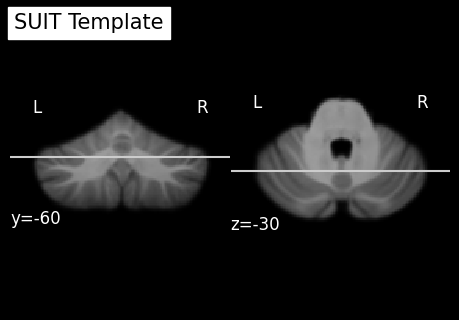

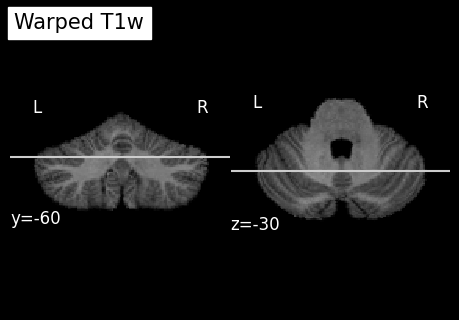

In [7]:
# Load normalized image
norm_img = nib.load('sub-ex_T1w_space-SUIT.nii.gz')
# Load SUIT template from SUITPy package
template_img = nib.load(os.path.join(os.path.dirname(suit.__file__), 'templates', 'tpl-SUIT_T1w.nii.gz'))
# Visualize the result
npl.plot_anat(template_img, title='SUIT Template', display_mode='yz', cut_coords=(-60, -30), colorbar=False)
npl.plot_anat(norm_img, title='Warped T1w', display_mode='yz', cut_coords=(-60, -30), colorbar=False)


## 3. Group-level analysis

Once the log-detJ and detJ maps have been computed for all subjects, group-level
statistics can be applied directly to these maps using any standard
statistical framework (e.g., nilearn, scipy, FSL). SUITPy ensures that all
cerebellar data are aligned to a common template, but does not provide a
group analysis framework itself.

In practice, a group DBM analysis involves:

* Applying a voxel-wise statistical model to the log-detJ maps, such as:
  * A one-sample t-test against zero (H0: no volume difference relative to
    the template)
  * An independent-samples t-test to compare two groups
  * A GLM with covariates (age, behavior, clinical scores, etc.)
* Correcting for multiple comparisons (FDR, cluster-based correction, TFCE).

For modulated Voxel-Based Morphometry (VBM) analysis, the detJ map can
additionally be used to modulate grey matter probability maps prior to
group analysis.


## 4. Visualize individual volume differences on the flatmap


The log-detJ map shows the spatial distribution of local volumetric differences
between the individual cerebellum and the template. Positive values indicate
that the subject's local volume is larger than the template; negative values
indicate smaller volume. Note that the main baseline difference is simply caused by
the overall head size (intracranial volume). 
Therefore, it is common to include intracranial volume as a covariate in group-level analysis. 

To plot the mapped data on the flatmap, use ``flatmap.plot``:


<Axes: >

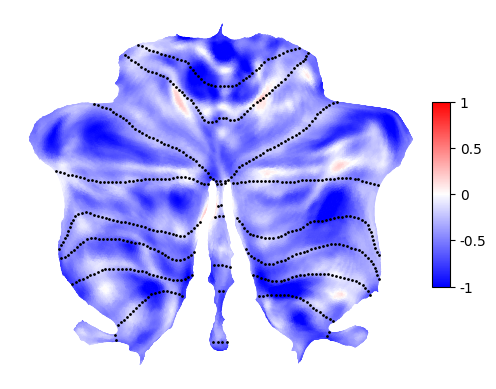

In [8]:
jd_surf = suit.vol_to_surf('sub-ex_T1w_to-SUIT_mode-image_log_detJ.nii.gz', space='SUIT')

# Visualize the log-detJ on the flatmap
# Positive values: subject locally larger than template
# Negative values: subject locally smaller than template
suit.flatmap.plot(data=jd_surf,
                  cmap='bwr',
                  cscale=[-1, 1],
                  threshold=None,
                  new_figure=False,
                  colorbar=True,
                  render='matplotlib')


## 5. Summarize regional volumes with atlas ROI
While the SUIT pipeline provides voxel-wise estimates of local volume differences, 
it can also be useful to summarize these differences at the level of predefined regions. 
One approach is to inversely transform an atlas from template space to native space and then 
count the voxels in native space. 

Equivalently, the same (or at least very close) result can be obtained by averaging the detJ values within each region, 
and then multiplying it by the volume of the region in template space,which gives an estimate of the total volume in native space. This approach is computationally more efficient.

The ``mean`` of detJ values within a region,
multiplied by the template ROI volume, gives the estimated regional
volume in mm³.

To download cerebellar atlases, see `Cerebellar Atlases` or go directly to the
[Atlas repository](https://github.com/DiedrichsenLab/cerebellar_atlases).

The function ``summarize_data`` then computes summary statistics inside each
atlas region and returns the results as a ``pandas.DataFrame``.


In [ ]:
# compute the volume of a single voxel
detJ_file = 'sub-ex_T1w_to-SUIT_mode-image_detJ.nii.gz'

# Summarize the jacobian
df = suit.summarize_data(
    images = [detJ_file],
    atlas  = 'Nettekoven_2024',
    maps   = 'atl-NettekovenSym32',
    space  = 'SUIT',
    stats  = ['mean'])

# Multiply by voxel-volume and look at result
df['ind_vol'] = df['mean'] * df['volume']
print(df[['region', 'regionname', 'ind_vol']].head())


   region regionname      ind_vol
0       1        M1L  1244.860567
1       2        M2L  5450.457440
2       3        M3L  5170.741903
3       4        M4L  2974.023967
4       5        A1L   685.792017
